[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bernardorivas/wael/blob/main/notebooks/example1_toggle_switch.ipynb)

# Example 1. Toggle switch

Given a parameter sample in DSGRN region 4, this notebook simulates the toggle switch as a Hill system and, after adding noise, infers the parameters back with least squares and a PINN. Recovery is evaluated by DSGRN region membership.

In [1]:
%pip install -q DSGRN
%pip install -q tqdm git+https://github.com/marciogameiro/DSGRN_utils.git

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.stats import qmc
import torch, torch.nn as nn
import DSGRN, DSGRN_utils
np.set_printoptions(precision=3, suppress=True)

# Train on a GPU when one is available: CUDA on Colab, MPS on Apple silicon, otherwise CPU.
# Note that MPS is single precision only, so CUDA is set to float32 for reproducibility.
if torch.cuda.is_available():
    DEVICE, TORCH_DTYPE = torch.device('cuda'), torch.float32
elif torch.backends.mps.is_available():
    DEVICE, TORCH_DTYPE = torch.device('mps'), torch.float32
else:
    DEVICE, TORCH_DTYPE = torch.device('cpu'), torch.float64
torch.set_default_dtype(TORCH_DTYPE)
print('torch device:', DEVICE, '| dtype:', TORCH_DTYPE)

torch device: mps | dtype: torch.float32


### Hill functions

The production is built from Hill functions
\begin{equation}
f^+(x,L,U,\theta,d) = L + (U-L) \frac{x^d}{x^d+\theta^d}, \quad
f^-(x,L,U,\theta,d) = L + (U-L) \frac{\theta^d}{x^d+\theta^d}
\end{equation}
where
*   `L` and `U` are lower and upper values,
*   `theta` is a threshold value,
*   `d` is the steepness coefficient.

We use `f+` when it is activating and `f-` when it is repressing, noting that $f^++f^-=L+U$.

We define `hill_act` and `hill_rep` below, both in NumPy for simulation and in torch for the PINN's physics loss.

In [3]:
# --- Hill production functions: smooth switches (gamma normalized to 1) ---
def hill_act(x, L, U, th, d):   # activating: low L -> high U as x rises
    xd = np.power(x, d); td = np.power(th, d)
    return L + (U - L) * xd / (td + xd)

def hill_rep(x, L, U, th, d):   # repressing: high U -> low L as x rises
    xd = np.power(x, d); td = np.power(th, d)
    return L + (U - L) * td / (td + xd)

In [4]:
# --- the same two functions in torch (used inside the network's physics loss) ---
def hill_act_t(x, L, U, th, d):
    xd = x.clamp(min=1e-9).pow(d); td = th.pow(d)
    return L + (U - L) * xd / (td + xd)

def hill_rep_t(x, L, U, th, d):
    xd = x.clamp(min=1e-9).pow(d); td = th.pow(d)
    return L + (U - L) * td / (td + xd)

## 1. Model and DSGRN region

Consider the planar system given by

$$\dot{x}_1=-\gamma_1 x_1+f^-(x_2),\qquad \dot{x}_2=-\gamma_2 x_2+f^-(x_1),\qquad \gamma_1=\gamma_2=1.$$

The DSGRN region decomposition associates region 4 with the inequalities
$$0 < L < \gamma\,\theta < U.$$
Membership is tested with DSGRN: `to_matrices` packs `(L, U, theta)` into DSGRN's parameter matrices, `par_index_from_sample` returns the region index.

In [5]:
P = dict(L10=1.0, U10=5.0, th10=3.0, d10=10.0,
         L01=1.0, U01=5.0, th01=3.0, d01=10.0, g=1.0)

def rhs(t, x, p):
    x1, x2 = x
    return [-p['g']*x1 + hill_rep(x2, p['L10'], p['U10'], p['th10'], p['d10']),
            -p['g']*x2 + hill_rep(x1, p['L01'], p['U01'], p['th01'], p['d01'])]

NET_SPEC = 'x : ~y\ny : ~x\n'
_net = DSGRN.Network(NET_SPEC); _pg = DSGRN.ParameterGraph(_net)
TARGET = 4
EDGES = [(1, 0), (0, 1)]         # y->x and x->y
def to_matrices(p):              # per-edge (L, U, theta) -> DSGRN L, U, T matrices
    L = np.zeros((2, 2)); U = np.zeros((2, 2)); T = np.zeros((2, 2))
    for (i, j) in EDGES:
        L[i, j] = p[f'L{i}{j}']; U[i, j] = p[f'U{i}{j}']; T[i, j] = p[f'th{i}{j}']
    return L, U, T
def region_of(p):                # parameters -> DSGRN region index (-1 if outside)
    return DSGRN.par_index_from_sample(_pg, *to_matrices(p))
def in_region(p):                # membership in the target region
    return region_of(p) == TARGET

print('do the true parameters lie in the bistable region?', in_region(P), '| region', region_of(P))

do the true parameters lie in the bistable region? True | region 4


## 2. Synthetic data

Ground truth parameters lie in region 4. Now the ODE is numerically integrated from several initial conditions and the trajectories are taken as measurements.

In [6]:
def simulate(rhs, p, x0, T, n):
    t = np.linspace(0.0, T, n)
    sol = solve_ivp(rhs, (0.0, T), x0, t_eval=t, args=(p,), rtol=1e-9, atol=1e-11)
    return t, sol.y.T   # times (n,), states (n, m)

def add_noise(y, ub_frac, scale, rng):
    yn = y + rng.uniform(-ub_frac*scale, ub_frac*scale, size=y.shape)
    return np.clip(yn, 0.0, None)   # concentrations stay non-negative

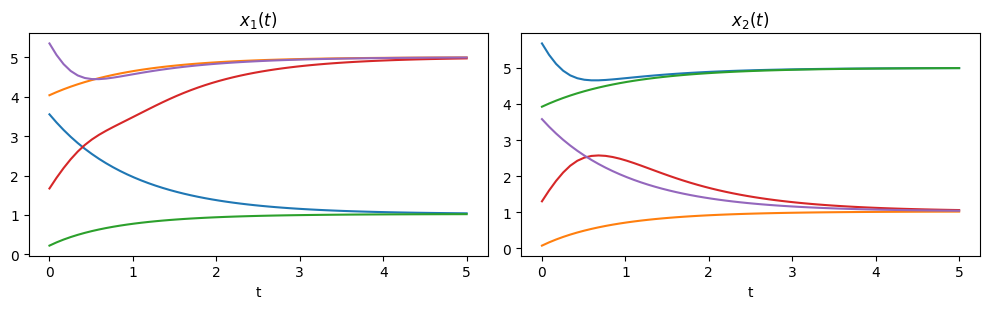

final states: [1.042 4.994] [4.993 1.02 ] [1.021 4.993] [4.969 1.062] [4.992 1.044]


In [7]:
T, n = 5.0, 60
MARGIN = 1.2
box_hi = [MARGIN*P['U10'], MARGIN*P['U01']]
n_ic = 5
x0s = qmc.scale(qmc.LatinHypercube(d=2, seed=0, optimization='random-cd').random(n_ic), [0.0, 0.0], box_hi).tolist()
ts, xs = [], []
for x0 in x0s:
    t, y = simulate(rhs, P, x0, T, n); ts.append(t); xs.append(y)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for x0, t, y in zip(x0s, ts, xs):
    ax[0].plot(t, y[:, 0]); ax[1].plot(t, y[:, 1])
ax[0].set_title('$x_1(t)$'); ax[1].set_title('$x_2(t)$')
for a in ax: a.set_xlabel('t')
plt.tight_layout(); plt.show()
print('final states:', *[np.round(y[-1], 3) for y in xs])

## 3. Measurement noise

We add a bounded uniform noise, scaled by the difference `U - L`, to the trajectories. The recovery methods see only the noisy data.

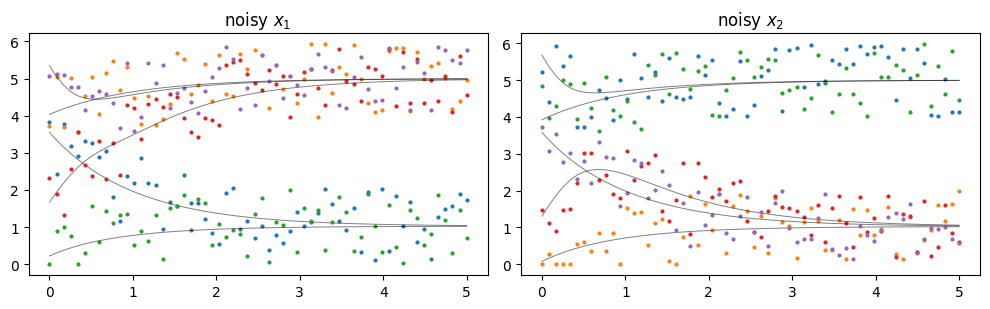

In [8]:
rng = np.random.default_rng(0)
gap = P['U10'] - P['L10']
ub = 0.25                      # noise up to 25% of the characteristic scale
xs_noisy = [add_noise(y, ub, gap, rng) for y in xs]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for t, y, yn in zip(ts, xs, xs_noisy):
    ax[0].plot(t, yn[:, 0], '.', ms=4); ax[0].plot(t, y[:, 0], 'k-', lw=.7, alpha=.5)
    ax[1].plot(t, yn[:, 1], '.', ms=4); ax[1].plot(t, y[:, 1], 'k-', lw=.7, alpha=.5)
ax[0].set_title('noisy $x_1$'); ax[1].set_title('noisy $x_2$')
plt.tight_layout(); plt.show()

## 4. Least-squares baseline

Slopes $\dot{x}$ are estimated by finite differences and `(L, U, theta, d)` fit to match them, with `gamma` fixed. Only `(L, U, theta)` are scored.

In [11]:
EDGE_KEYS = ['L10','U10','th10','d10', 'L01','U01','th01','d01']
def ls_recover(ts, xs, g=1.0):
    X = np.vstack(xs)
    DX = np.vstack([np.gradient(y, t, axis=0) for t, y in zip(ts, xs)])   # f from data
    scale = np.maximum(np.std(DX, axis=0), 1e-6)                          # per-coordinate weight
    def resid(z):
        p = dict(zip(EDGE_KEYS, z))
        f1 = -g*X[:, 0] + hill_rep(X[:, 1], p['L10'], p['U10'], p['th10'], p['d10'])
        f2 = -g*X[:, 1] + hill_rep(X[:, 0], p['L01'], p['U01'], p['th01'], p['d01'])
        return np.concatenate([(DX[:, 0] - f1)/scale[0], (DX[:, 1] - f2)/scale[1]])
    lb = [0, 0, 0, 0.25] * 2
    ub = [20, 20, 20, 80] * 2
    z0 = [0.5, 3.0, 2.0, 8.0] * 2
    s = least_squares(resid, z0, bounds=(lb, ub), loss='soft_l1')
    p = dict(zip(EDGE_KEYS, s.x)); p['g'] = g; return p

p_ls = ls_recover(ts, xs_noisy)
print('least-squares lands in the bistable region?', in_region(p_ls), '| region', region_of(p_ls))

least-squares lands in the bistable region? True | region 4


## 5. Physics-informed neural network

A network `u_theta(t, x0)` is trained to fit the data while its time derivative satisfies the ODE, jointly learning `(L, U, theta, d)` from a neutral init (`L ~ 0, U ~ 1, theta ~ 1, d = 5`) with `gamma` fixed at 1. The loss combines trajectory error, the physics residual `||du/dt - f(u)||`, and the initial condition mismatch. Only `(L, U, theta)` are scored.

In [ ]:
def build_tensors(ts, xs, x0s):
    # flatten all trajectories into (N,1) time, (N,m) repeated x0, (N,m) measured states
    t_d = np.concatenate([t[:, None] for t in ts])
    x_d = np.vstack(xs)
    x0_d = np.vstack([np.tile(x0, (len(t), 1)) for x0, t in zip(x0s, ts)])
    t_ic = np.zeros((len(x0s), 1)); x_ic = np.array(x0s, dtype=float)  # t=0 anchors
    to = lambda a: torch.tensor(a, dtype=torch.get_default_dtype(), device=DEVICE)
    return (to(t_d), to(x0_d), to(x_d), to(t_ic), to(x_ic))

In [ ]:
# --- the physics-informed network: surrogate u_theta(t, x0) + learnable (L,U,theta,d) ---
class PINN(nn.Module):
    def __init__(self, m, param_init, T, hidden=64, depth=4):
        super().__init__()
        self.m, self.T = m, T
        in_dim = 1 + m
        layers, d0 = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d0, hidden), nn.Tanh()]; d0 = hidden
        layers += [nn.Linear(d0, m)]
        self.net = nn.Sequential(*layers)
        # physical parameters via positive reparametrization  p = raw^2 + eps
        self.raw = nn.ParameterDict(
            {k: nn.Parameter(torch.tensor(float(v)**0.5)) for k, v in param_init.items()})

    def phys_params(self):
        return {k: self.raw[k]**2 + 1e-6 for k in self.raw}

    def _feat(self, t):
        return t / self.T   # normalize time to [0,1]; the chain rule is handled by autograd

    def forward(self, t, x0):
        return self.net(torch.cat([self._feat(t), x0], dim=1))

def fit_pinn(model, data, rhs_t, steps=4000, lr=1e-3, w=(5.0, 1.0, 1.0), log=500):
    t_d, x0_d, x_d, t_ic, x_ic = data   # all tensors
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for it in range(steps):
        opt.zero_grad()
        loss_data = ((model(t_d, x0_d) - x_d)**2).mean()           # fit the measurements
        tc = t_d.clone().requires_grad_(True)                       # physics residual:
        u = model(tc, x0_d)                                         #   du/dt should equal f(u)
        grads = [torch.autograd.grad(u[:, j].sum(), tc, create_graph=True)[0]
                 for j in range(model.m)]
        du = torch.cat(grads, dim=1)
        loss_phys = ((du - rhs_t(u, model.phys_params()))**2).mean()
        loss_ic = ((model(t_ic, x_ic) - x_ic)**2).mean()           # match initial conditions
        loss = w[0]*loss_data + w[1]*loss_phys + w[2]*loss_ic
        loss.backward(); opt.step()
        if log and it % log == 0:
            print(f'  step {it:5d}  data {loss_data.item():.2e}  phys {loss_phys.item():.2e}')
    return model

In [ ]:
def rhs_t(x, p):   # the same vector field, in torch, evaluated on network outputs
    x1, x2 = x[:, 0:1], x[:, 1:2]
    d1 = -x1 + hill_rep_t(x2, p['L10'], p['U10'], p['th10'], p['d10'])
    d2 = -x2 + hill_rep_t(x1, p['L01'], p['U01'], p['th01'], p['d01'])
    return torch.cat([d1, d2], dim=1)

init = {'L10':0.05,'U10':1.0,'th10':1.0,'d10':5.0,
        'L01':0.05,'U01':1.0,'th01':1.0,'d01':5.0}
torch.manual_seed(0)
model = PINN(m=2, param_init=init, T=T).to(DEVICE)
data = build_tensors(ts, xs_noisy, x0s)
model = fit_pinn(model, data, rhs_t, steps=4000, lr=1e-3)

pp = {k: float(v.detach()) for k, v in model.phys_params().items()}
print('PINN lands in the bistable region?', in_region(pp), '| region', region_of(pp))

## 6. Region recovery across noise

For each noise level (% of total bound), the least-squares fit is repeated over independent noisy datasets and the fraction landing in the target region is reported.

In [ ]:
levels = [0.0, 0.1, 0.25, 0.5]
n_trials = 20
rate = []
for ub in levels:
    r = np.random.default_rng(100); hits = 0
    for _ in range(n_trials):
        xs_n = [add_noise(y, ub, gap, r) for y in xs]
        hits += in_region(ls_recover(ts, xs_n))
    rate.append(hits / n_trials)
plt.plot([100*l for l in levels], rate, 'o-')
plt.xlabel('noise upper bound (%)'); plt.ylabel('region-recovery rate (LS)')
plt.ylim(-0.05, 1.05); plt.title('Toggle switch: region recovery vs noise'); plt.show()
print('LS region-recovery rate by noise level:', dict(zip(levels, rate)))

## Morse graph and Conley-index recovery (DSGRN)

There are two criteria per recovered parameter set: exact DSGRN region equality, and label-preserving isomorphism of the **Conley-Morse graph** (recurrent Morse sets, reachability order, Conley-index labels). Region equality implies isomorphic Morse graphs, so the second criterion is weaker than the first.

The cells below compare the recovered and target Morse graphs via `par_index_from_sample` (parameter sample to region index), `DSGRN_utils.ConleyMorseGraph` (region index to Morse graph), and `DSGRN.isomorphic_morse_graphs` (isomorphism of Morse graphs). For the target region we also plot the Morse sets in state space with `DSGRN_utils.PlotMorseSets` and the Conley-Morse graph with `DSGRN_utils.PlotMorseGraph`.

In [ ]:
# Conley-Morse graph for each region, reusing the network and TARGET from Section 1
_mg = {}
def conley_morse(idx):          # region index -> Conley-Morse graph (cached)
    if idx not in _mg:
        _mg[idx] = DSGRN_utils.ConleyMorseGraph(_pg.parameter(idx))[0]
    return _mg[idx]
def morse_recovers(idx, target=TARGET):   # same Conley-Morse graph up to label-preserving iso
    return idx >= 0 and DSGRN.isomorphic_morse_graphs(conley_morse(idx), conley_morse(target))

_cmg = DSGRN_utils.ConleyMorseGraph(_pg.parameter(TARGET))

In [ ]:
DSGRN_utils.PlotMorseSets(*_cmg)

In [ ]:
DSGRN_utils.PlotMorseGraph(_cmg[0])

In [ ]:
# the recovered parameters from the cells above
p_ls = ls_recover(ts, xs_noisy)
print('recovered region index:', region_of(p_ls),
      '| exact region match:', region_of(p_ls) == TARGET,
      '| Morse/Conley match:', morse_recovers(region_of(p_ls)))

# noise sweep: exact-region recovery vs Morse/Conley recovery (least squares)
levels = [0.0, 0.1, 0.25, 0.5]
print(f'{"noise":>6} | {"exact region":>12} | {"Morse/Conley":>12} | {"Morse-ok / miss":>16}')
for ub in levels:
    r = np.random.default_rng(7); reg = mor = gapc = 0
    for _ in range(15):
        xs_n = [add_noise(y, ub, gap, r) for y in xs]
        idx = region_of(ls_recover(ts, xs_n))
        er = (idx == TARGET); mr = morse_recovers(idx)
        reg += er; mor += mr; gapc += (mr and not er)
    miss = 15 - reg
    print(f'{ub:>6} | {reg:>10}/15 | {mor:>10}/15 | {f"{gapc}/{miss}":>16}')